# Daisyworld: параметры при изменении светимости

Сопоставим устойчивость четырёх комбинаций в сценарии ramp.

## Окружение и модель

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

savehistory (generic function with 1 method)

## Расчёт и полные временные ряды

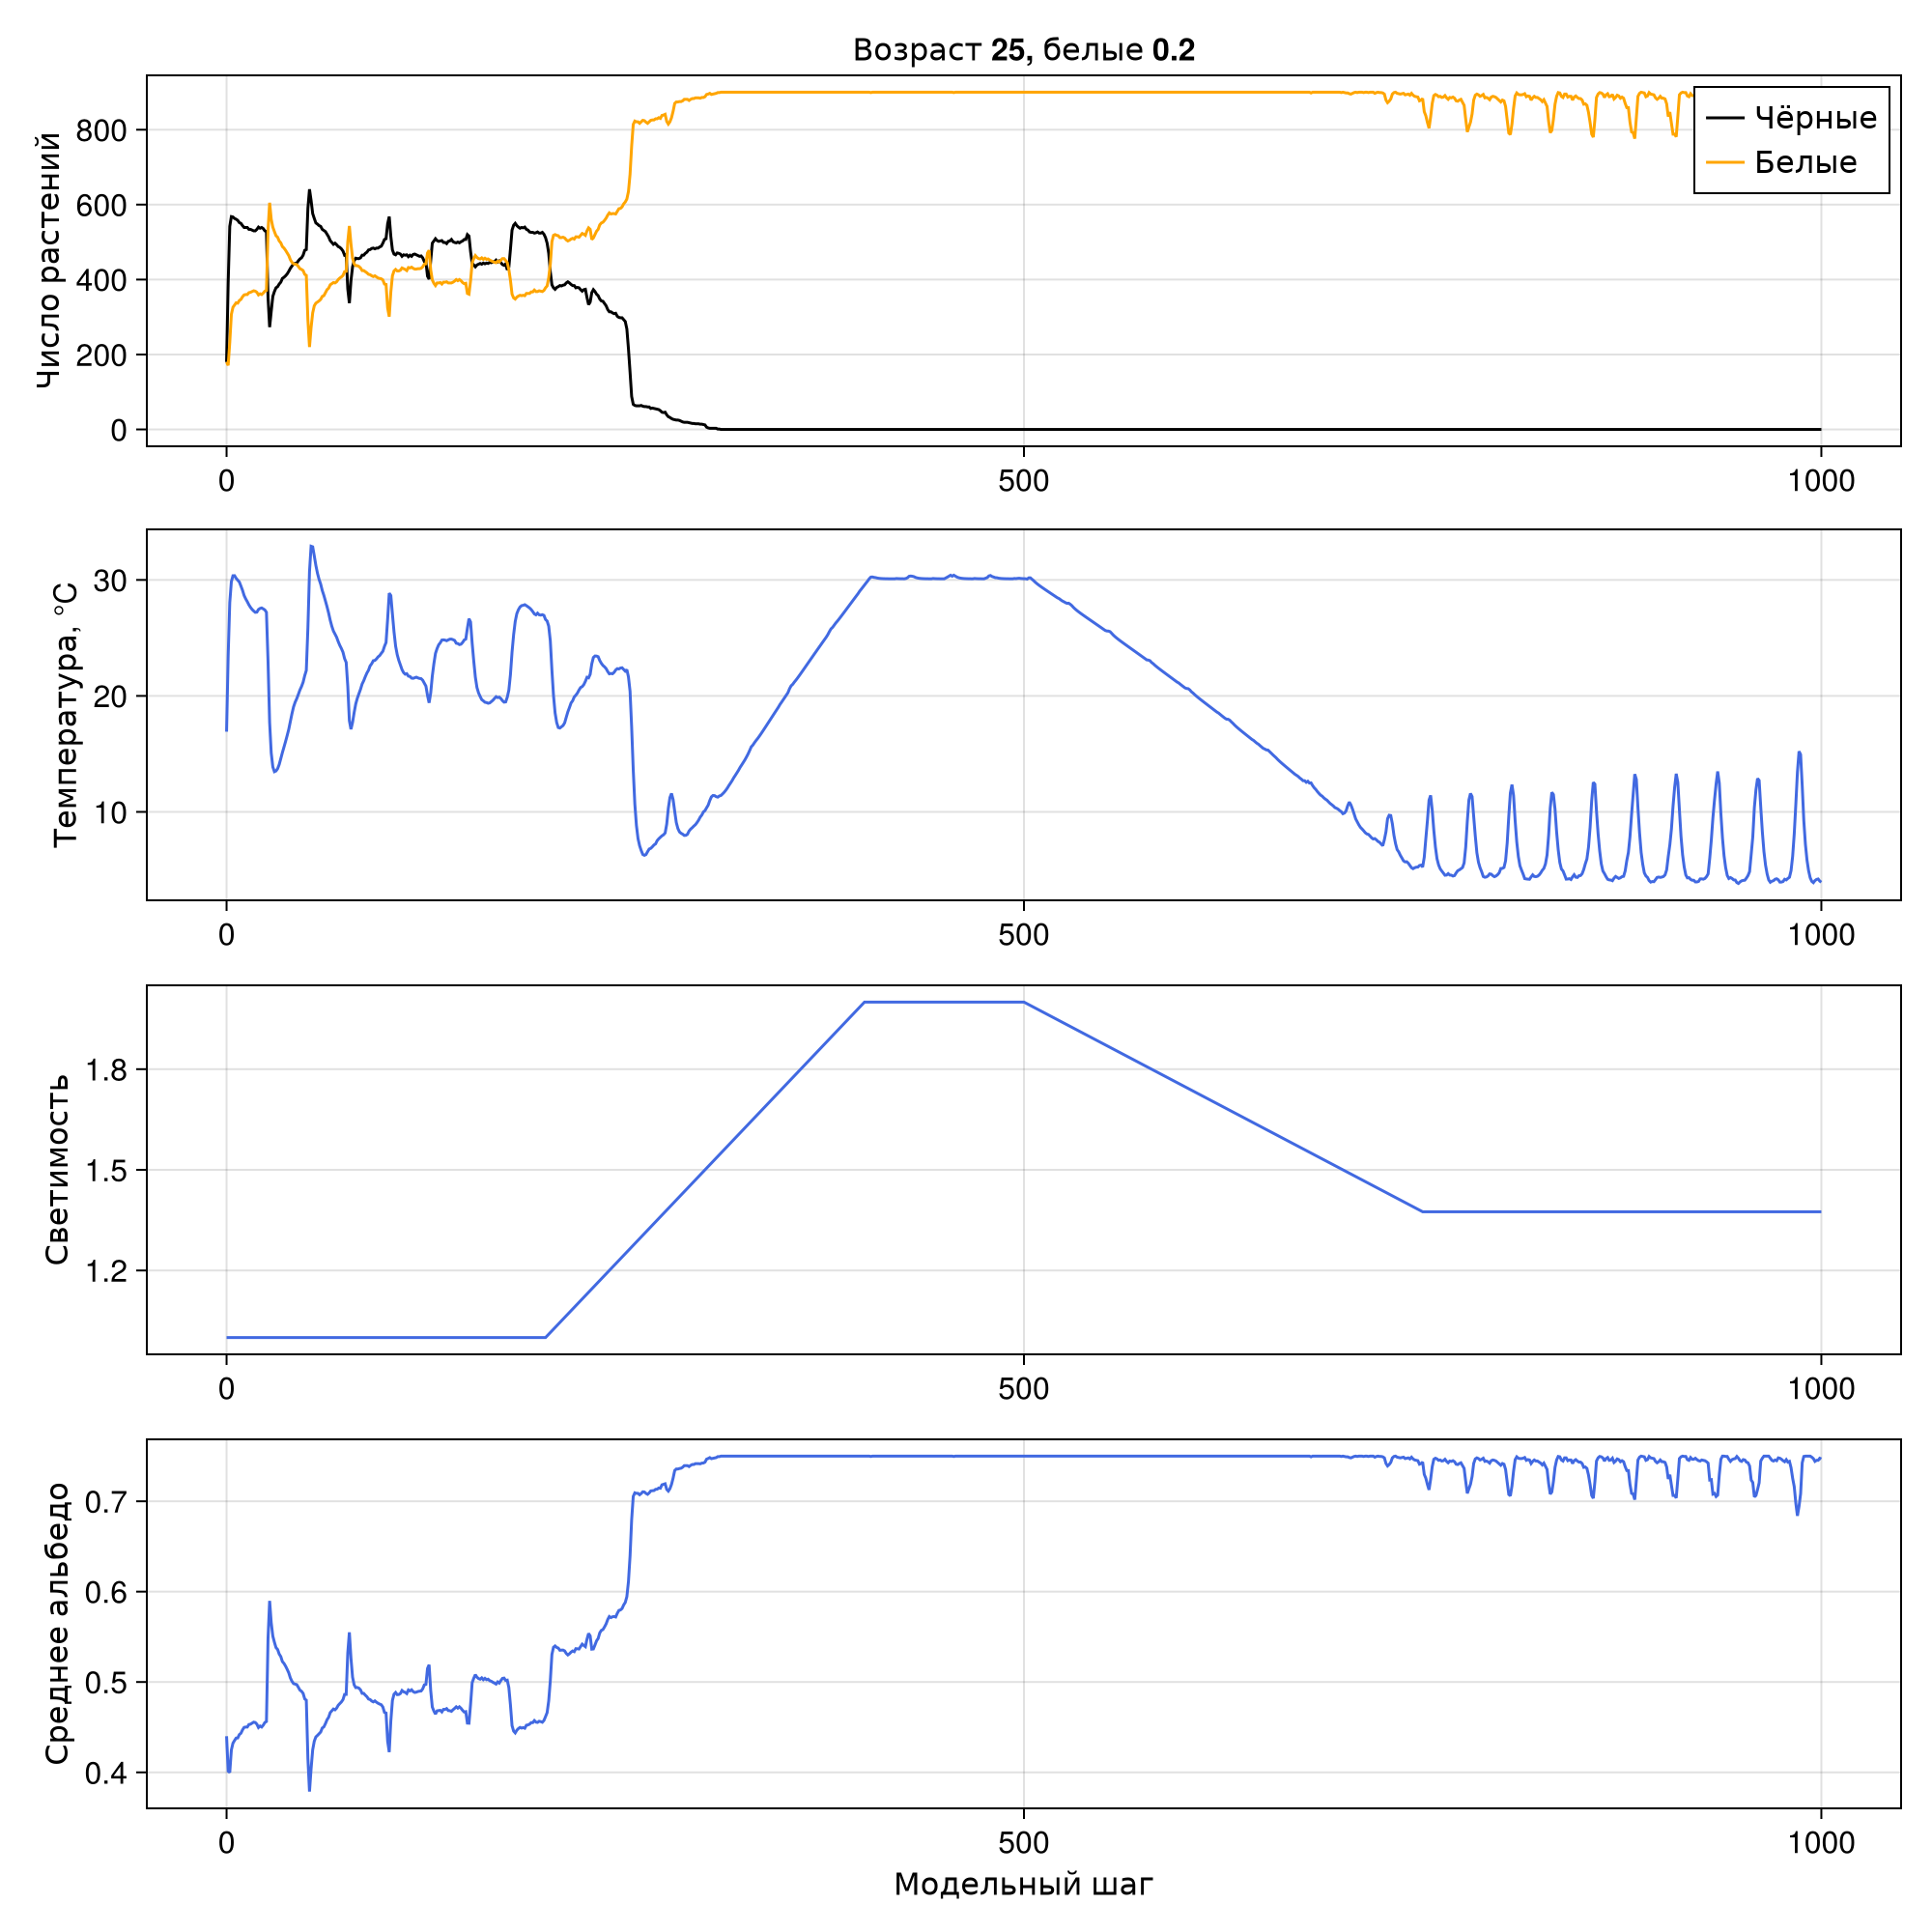

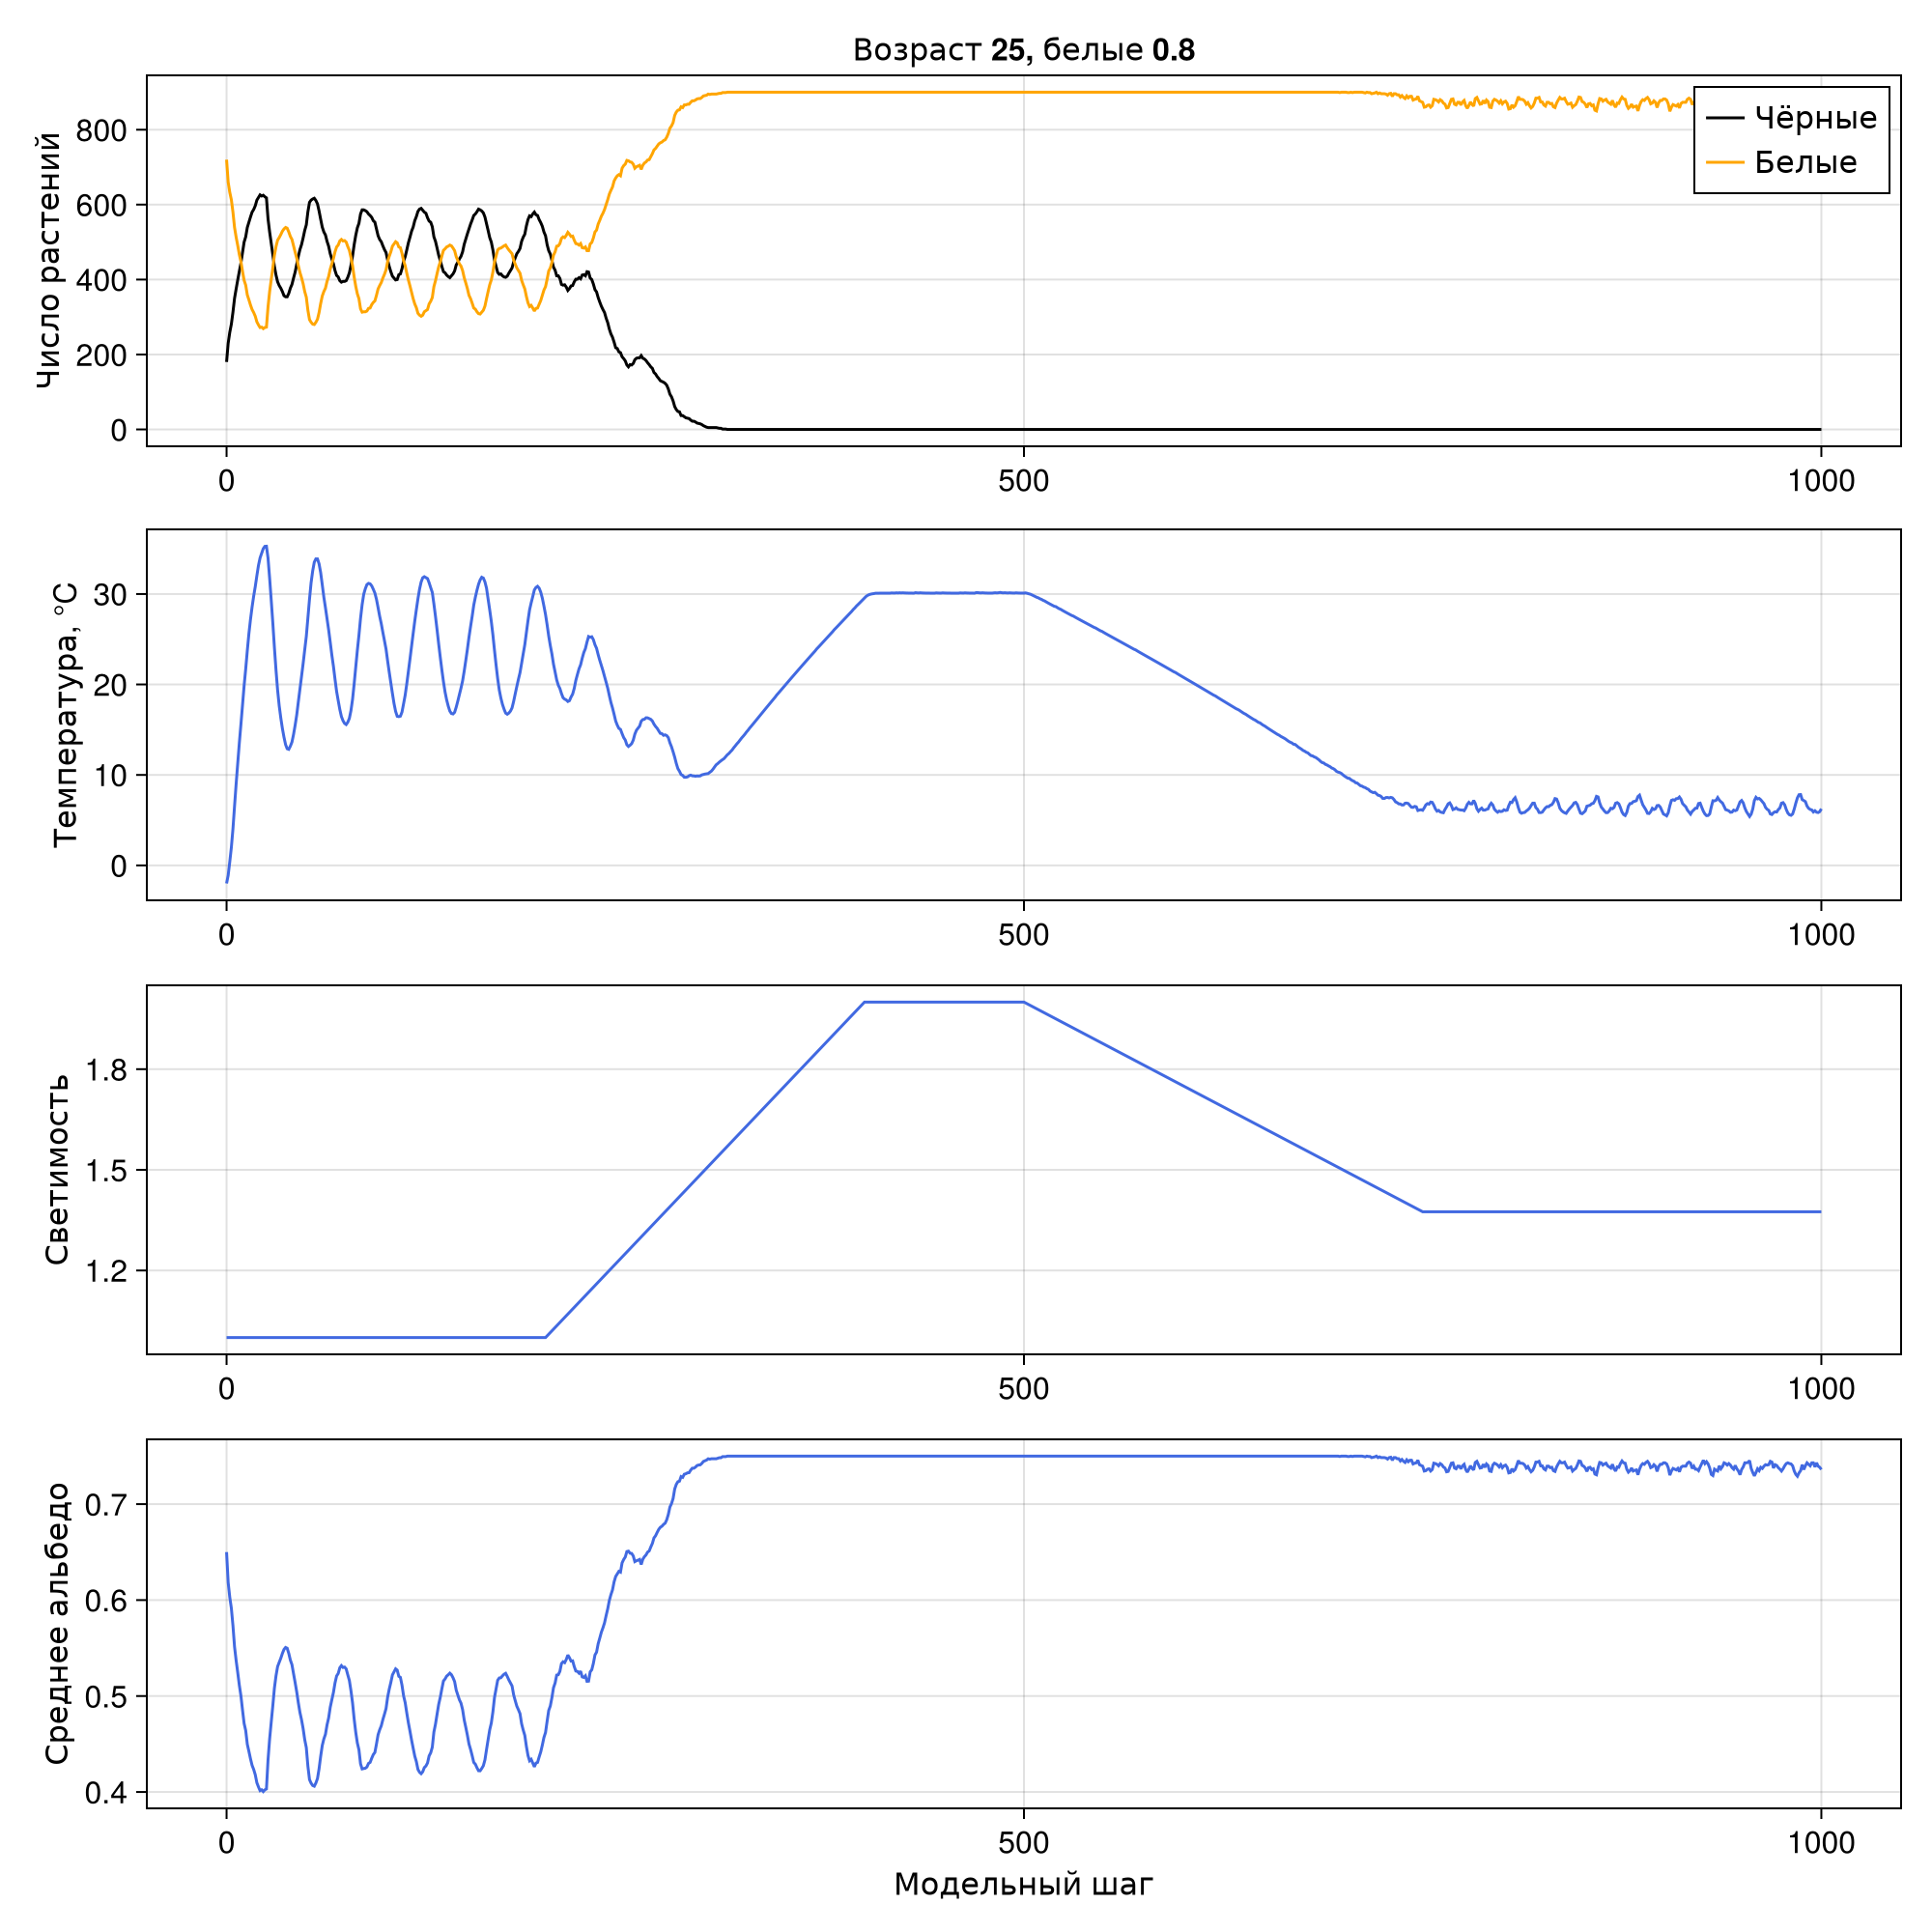

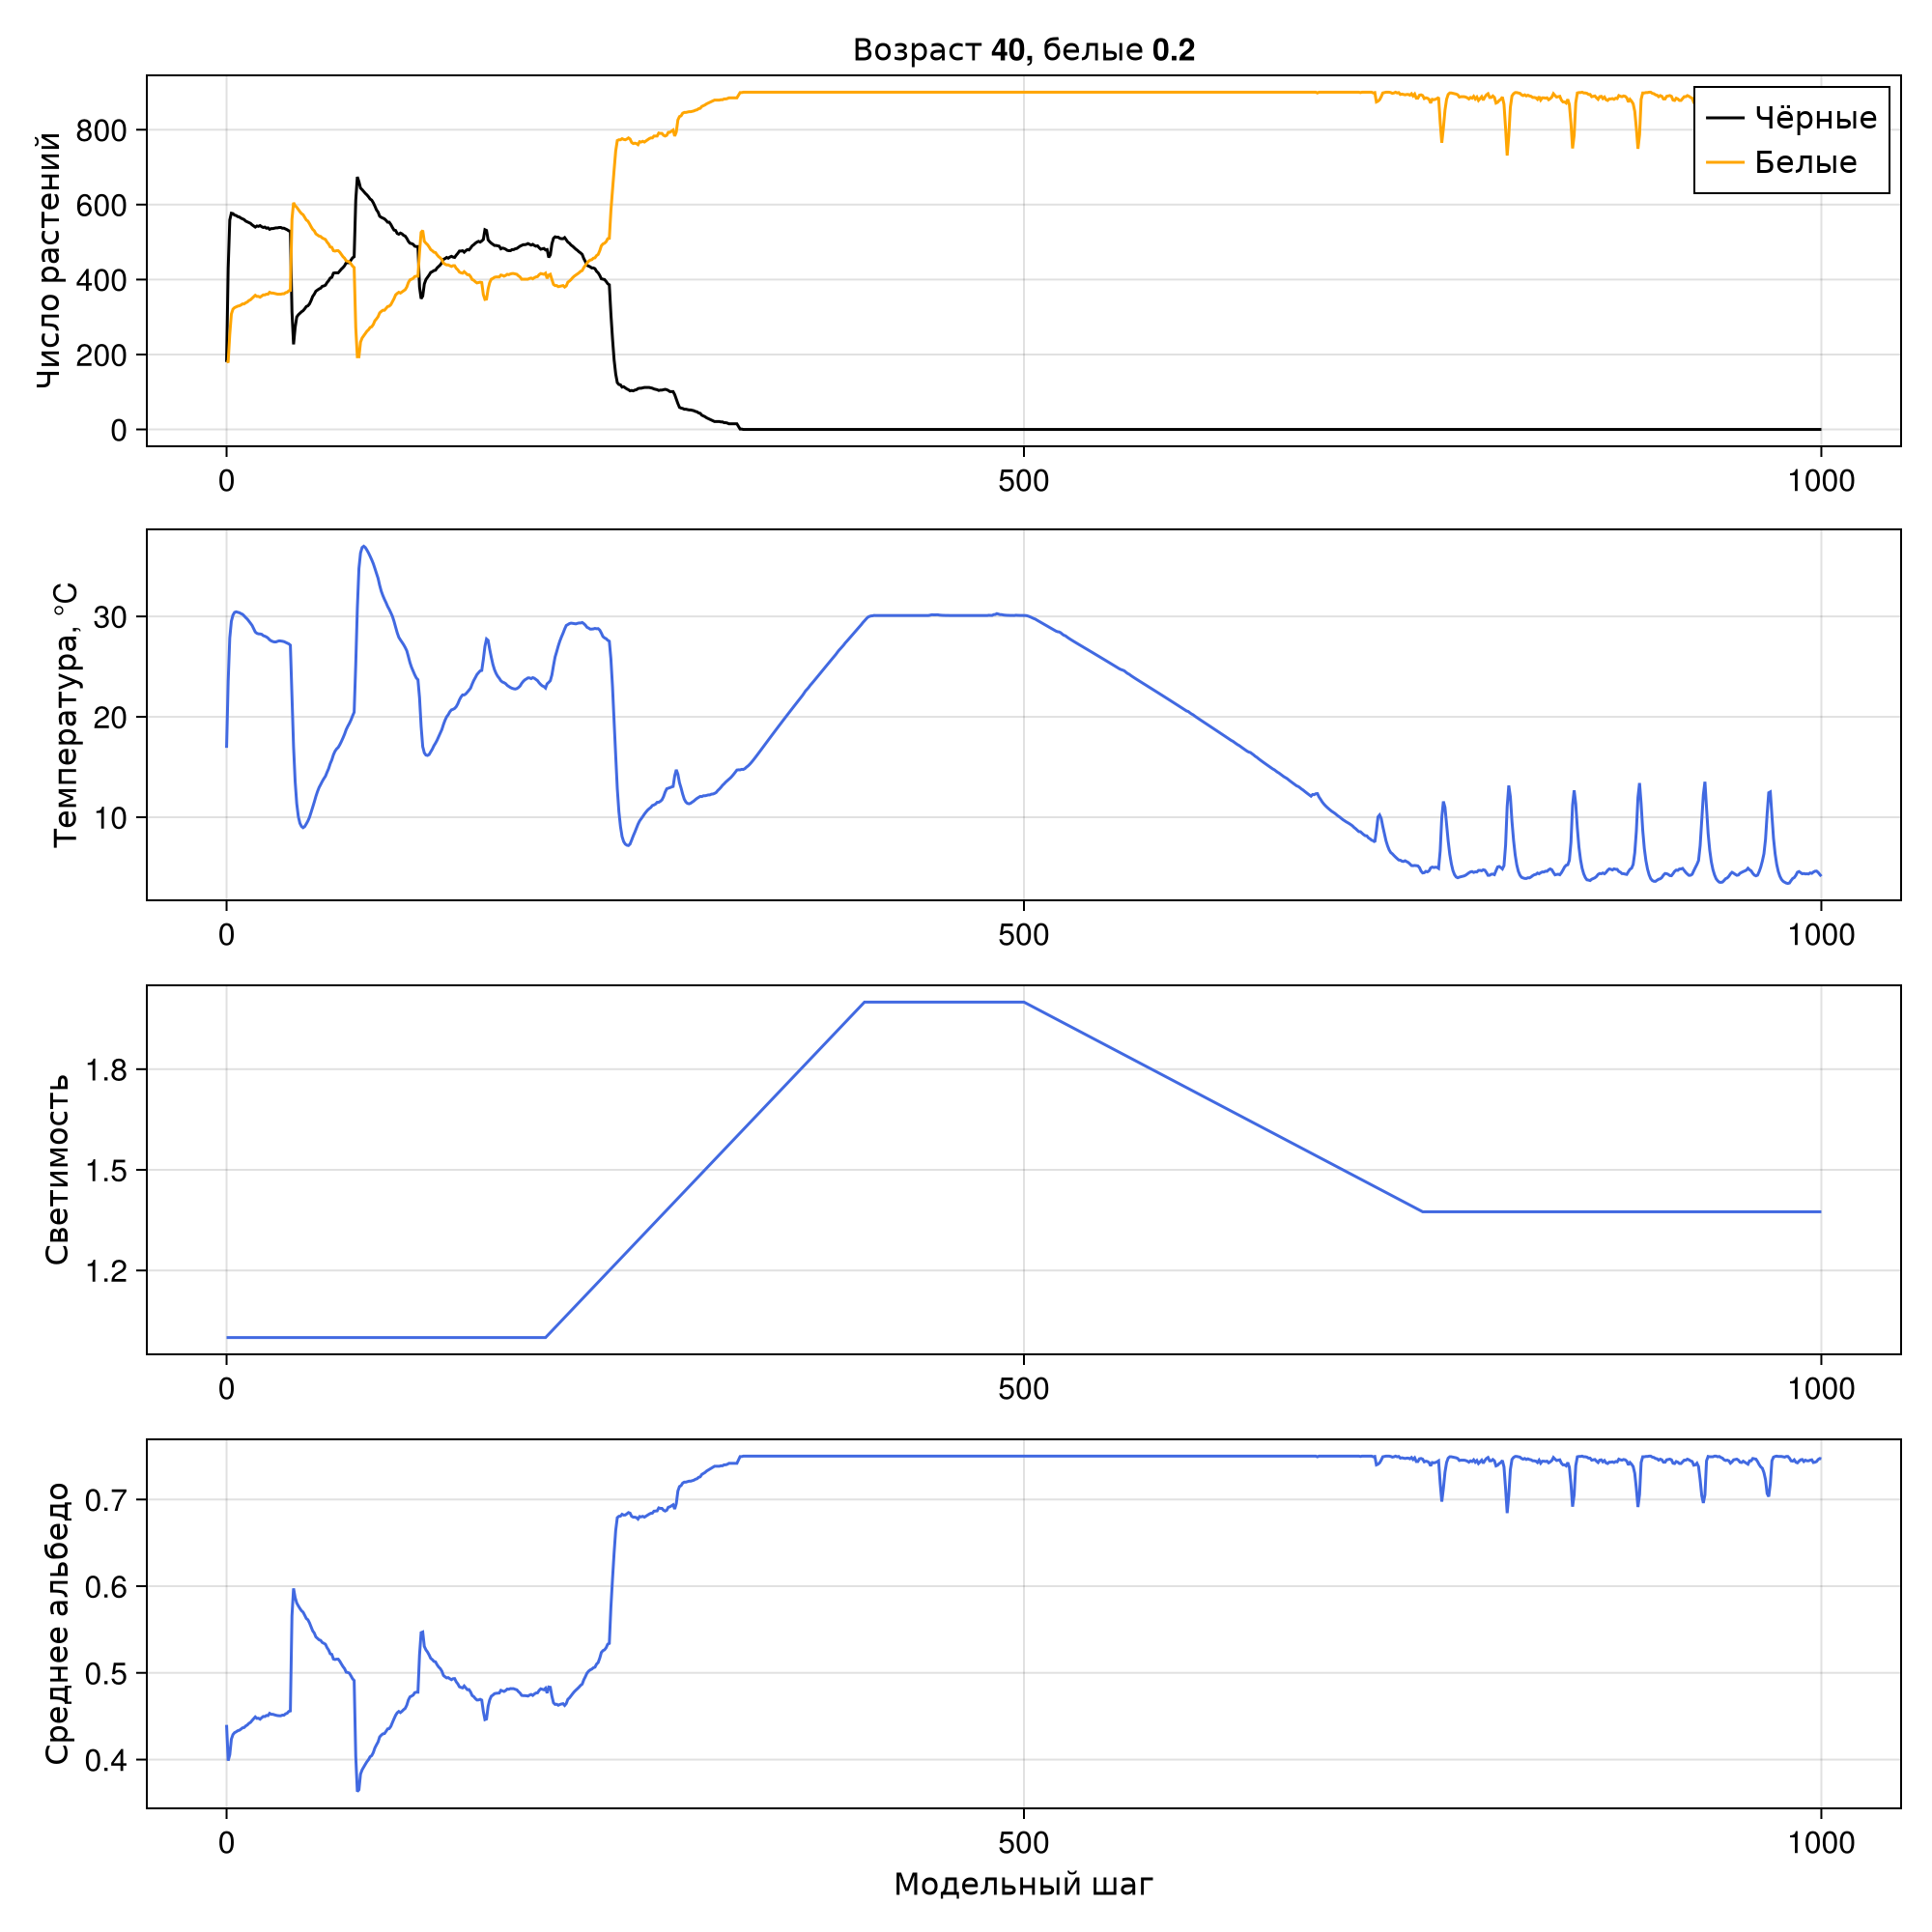

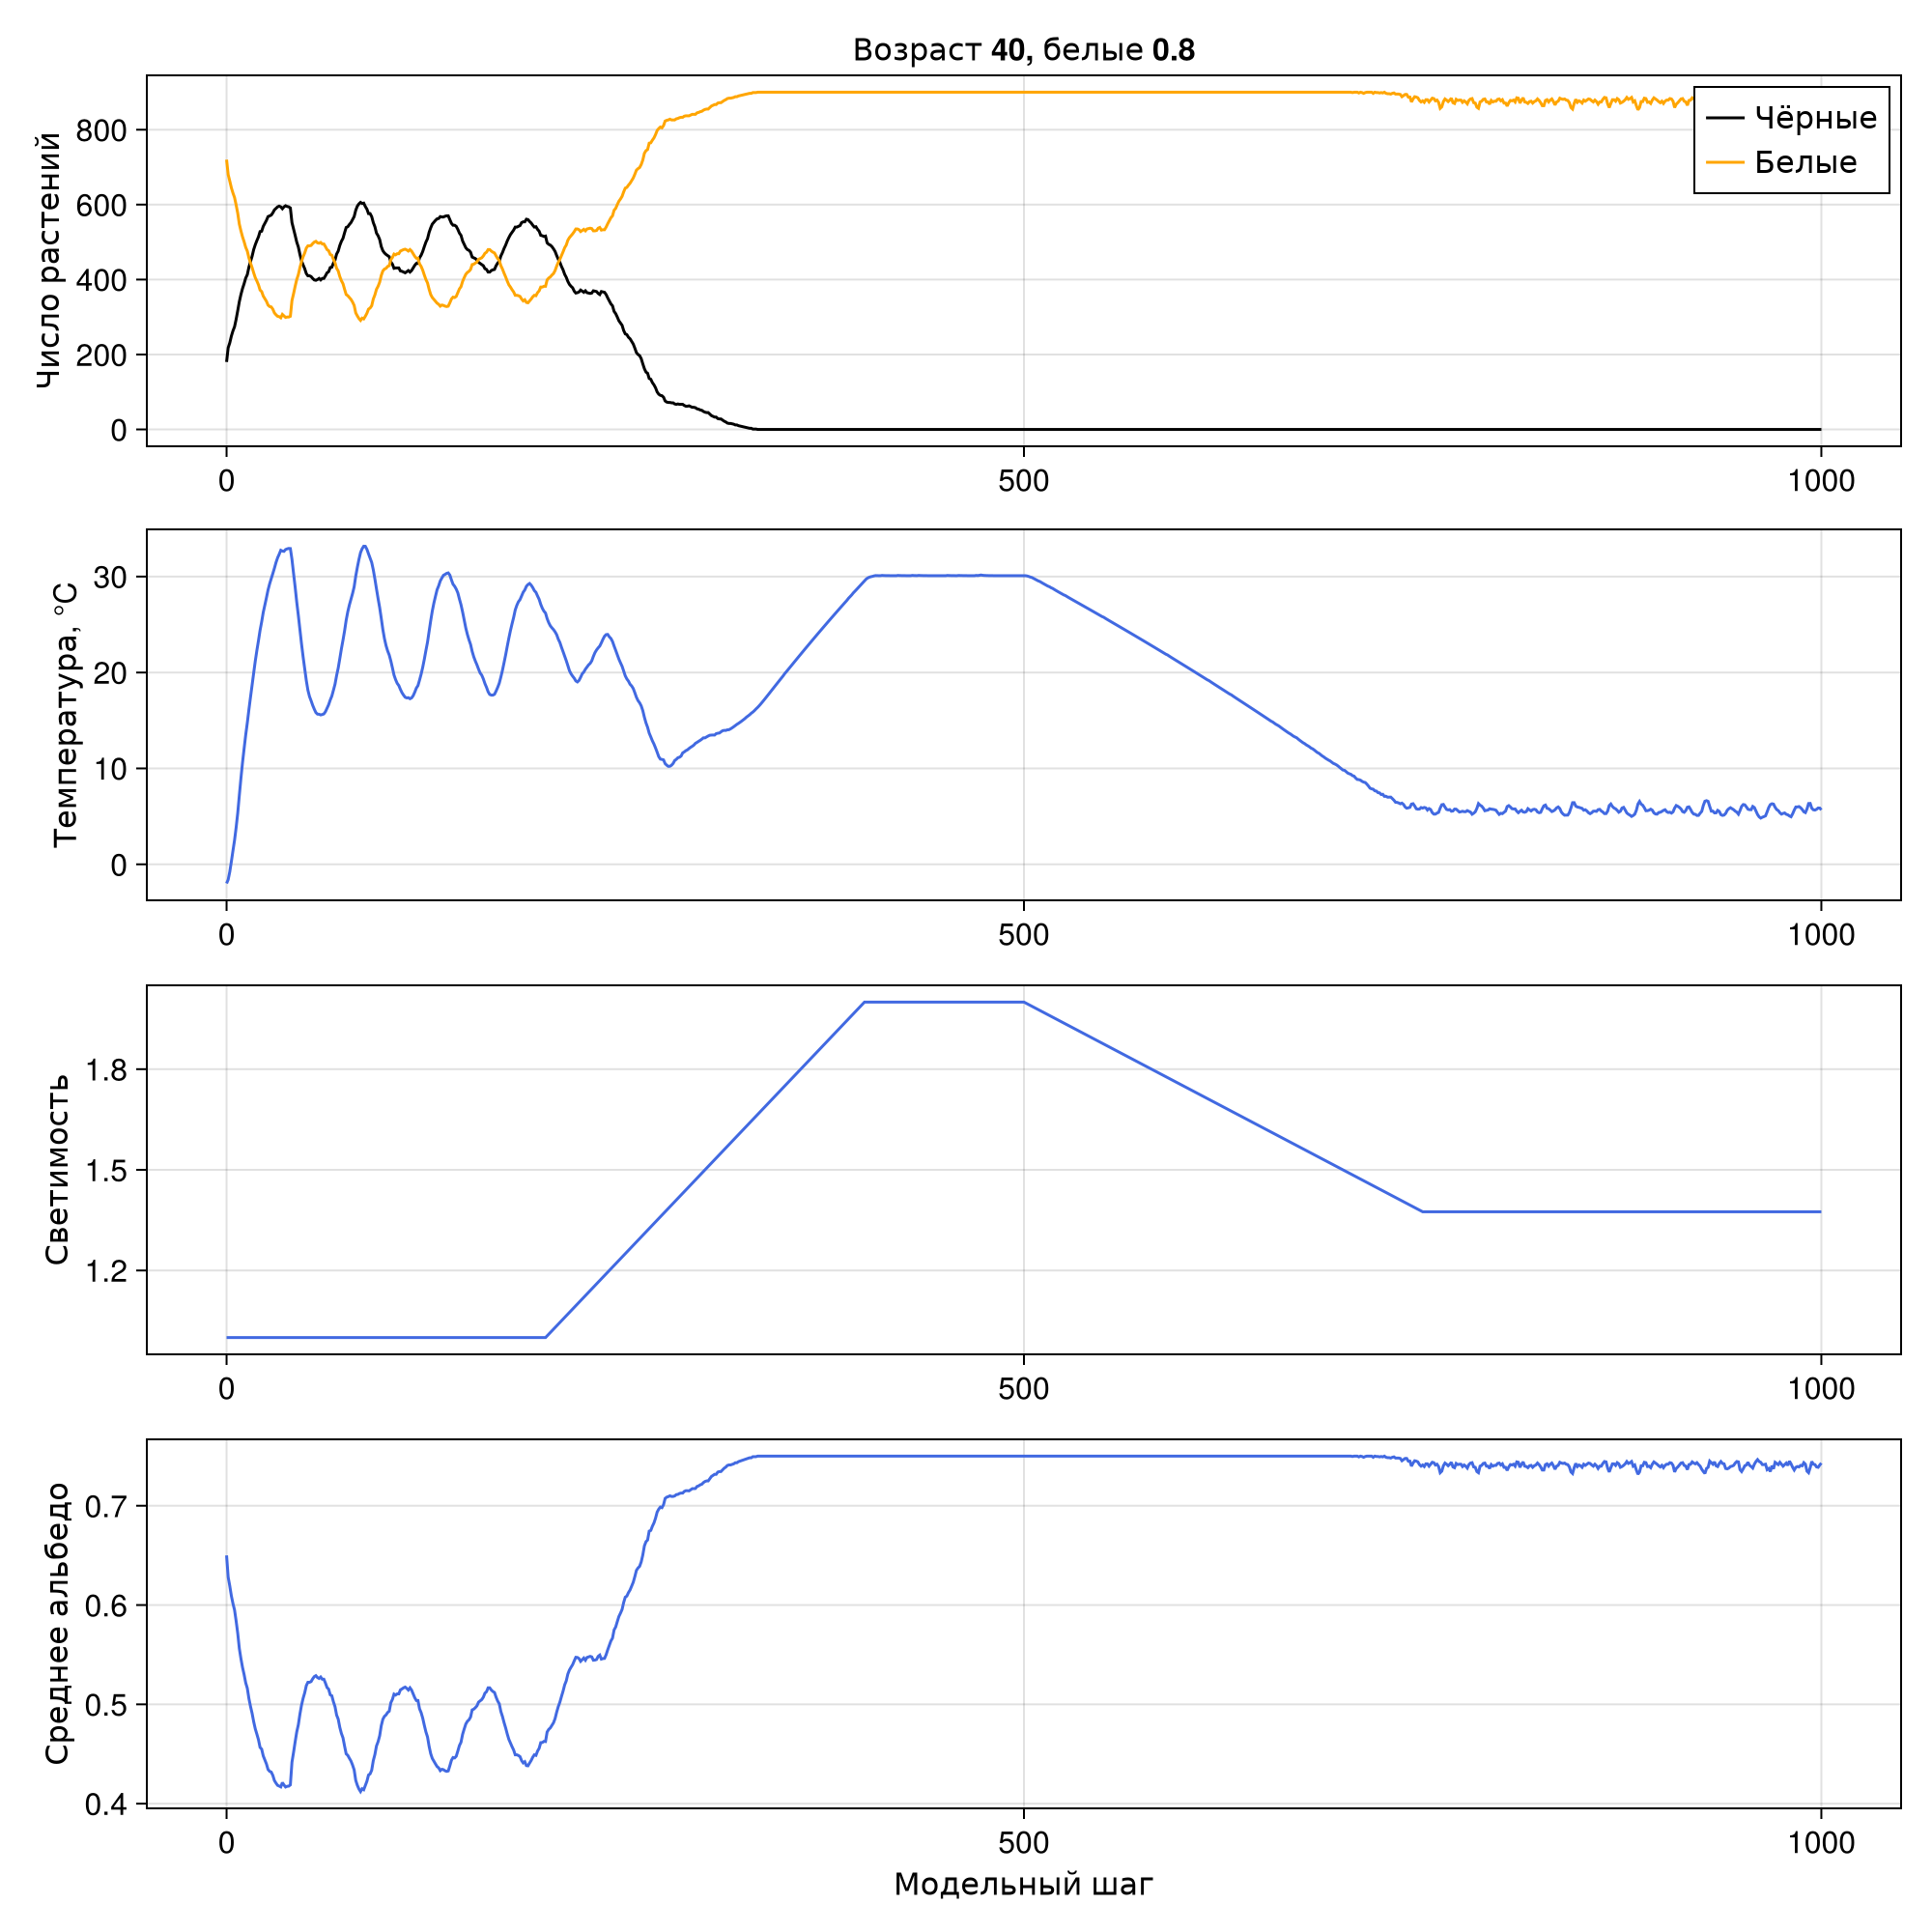

In [2]:
rows = NamedTuple[]
for (i, params) in enumerate(parameter_sets())
    model = daisyworld(; params..., scenario = :ramp)
    df = history(model, 1000)
    CSV.write(
        datafile("daisyworld-luminosity__param", "trajectory_$(i).csv"),
        df,
    )
    push!(
        rows,
        merge(
            (
                max_age = params[:max_age],
                init_white = params[:init_white],
            ),
            measure(model),
        ),
    )
    figure = dynamicsfigure(
        df;
        title = "Возраст $(params[:max_age]), белые $(params[:init_white])",
    )
    save(imagefile(lpad(21+i, 2, '0') * "-plot.png"), figure)
    display(figure)
end

## Сравнение конечных состояний

In [3]:
summary = DataFrame(rows)
CSV.write(
    datafile("daisyworld-luminosity__param", "summary.csv"),
    summary,
)
summary

Row,max_age,init_white,time,black,white,temperature,luminosity,albedo
,Int64,Float64,Int64,Int64,Int64,Float64,Float64,Float64
1,25,0.2,1000,0,892,3.93831,1.375,0.746889
2,25,0.8,1000,0,864,6.25753,1.375,0.736
3,40,0.2,1000,0,892,4.11542,1.375,0.746889
4,40,0.8,1000,0,882,5.66696,1.375,0.743
